In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

# --- constantes ----
CENTRAL_FLUX = 0
UPWIND_FLUX = 1

A = np.array([0.0,
-567301805773.0 / 1357537059087.0,
-2404267990393.0 / 2016746695238.0,
-3550918686646.0 / 2091501179385.0,
-1275806237668.0 / 842570457699.0])

B = np.array([1432997174477.0 / 9575080441755.0,
5161836677717.0 / 13612068292357.0,
1720146321549.0 / 2090206949498.0,
3134564353537.0 / 4481467310338.0,
2277821191437.0 / 14882151754819.0])

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)

# --- domínio ---
vp = 1.0
kx = 2 * np.pi
xl, xr = 0, 1

# --- retorna pontos GLL de ordem polinomial N ---
def get_GLL_nodes(N):
    internal_nodes, _ = scipy.special.roots_jacobi(N - 1, 1, 1)
    r = np.concatenate([[-1.0], internal_nodes, [1.0]]) # elemento de referência
    return r

# --- retorna pesos dos nós GLL de ordem polinomial N ---
def get_GLL_weights(nodes, N):
    N = len(nodes) - 1

    # Legendre polynomial of degree N
    P = scipy.special.legendre(N)

    # Evaluate P_N(x_i)
    PN = np.polyval(P, nodes)

    # Compute weights
    w = 2.0 / (N * (N + 1) * PN**2)

    return w

# --- retorna matriz D - diferenciação ---
def get_D_matrix(nodes):
    N = len(nodes) - 1
    w = np.ones(N + 1)
    
    for j in range(N + 1):
        for i in range(N + 1):
            if i != j:
                w[j] *= 1.0 / (nodes[j] - nodes[i])
    D = np.zeros((N + 1, N + 1))
    
    for i in range(N + 1):
        for j in range(N + 1):
            if i != j:
                D[i, j] = (w[j] / w[i]) / (nodes[i] - nodes[j])
        D[i, i] = -np.sum(D[i, :])
        
    return D

# --- retorna fluxo numérico ---
def numerical_flux(uL, uR, a, flux_type):
    match flux_type:
        case int(CENTRAL_FLUX):
            return 0.5 * a * (uL + uR)
        case int(UPWIND_FLUX):
            return a * uL if a > 0 else a * uR
        case _: # fallback central flux
            return 0.5 * a * (uL + uR)
    
# --- operador DG ---
def build_dg_operator(K, N, a, flux_type):
    dx_elem = (xr - xl) / K
    xi = get_GLL_nodes(N)
    D_ref = get_D_matrix(xi)
    D_phys = (2.0 / dx_elem) * D_ref
    w = get_GLL_weights(xi, N)
    M_local = w * dx_elem / 2.0
    
    # Coordenadas físicas dos nós
    x_nodes = np.zeros((K, N + 1))
    for k in range(K):
        xL = xl + k * dx_elem
        x_nodes[k, :] = xL + 0.5 * (xi + 1) * dx_elem
        
    return {
        'K': K, 'N': N, 'dx_elem': dx_elem,
        'D_phys': D_phys, 'M_local': M_local,
        'x_nodes': x_nodes, 'a': a, 'flux_type': flux_type
    }
    
def rhs(u_flat, op):
    K, N = op['K'], op['N']
    D = op['D_phys']
    M = op['M_local']
    a = op['a']
    flux_type = op['flux_type']
    
    u = u_flat.reshape((K, N + 1))
    du = np.zeros_like(u)
    
    for k in range(K):
        du[k, :] = -a * (D @ u[k, :])
        uL = u[k, N]
        uR = u[(k + 1) % K, 0]
        fstar_R = numerical_flux(uL, uR, a, flux_type)
        du[k, N] += a * (uL - fstar_R / a) / M[N] 
        
        uL_prev = u[(k - 1) % K, N]
        uR_curr = u[k, 0]
        fstar_L = numerical_flux(uL_prev, uR_curr, a, flux_type)
        du[k, 0] += a * (-uR_curr + fstar_L / a) / M[0] # note o sinal
        
    return du.flatten()

# low storage Range Kutta quarta ordem
def lsrk4_step(u, rhs_func, dt, op):
    q = np.zeros_like(u)
    for i in range(5):
        k = rhs_func(u, op)
        q = A[i] * q + dt * k
        u = u + B[i] * q
        
    return u

In [44]:
def run_simulation(K, N, CFL, T_final, a, kx, flux_type):
    # gera o operador
    op = build_dg_operator(K, N, a, flux_type)
    x_nodes = op['x_nodes']
    
    # Condição inicial
    u = np.sin(kx * x_nodes).flatten().copy()
    
    # discretização
    dx = op['dx_elem']
    dt = CFL * dx / (a * (N + 1) ** 2)
    Nt = max(1, int(T_final / dt))
    dt = T_final / Nt # evita erro de arrendondamento
    
    # snapshots
    u_history = []
    snapshots_list = np.linspace(0, Nt - 10, 6)
    
    print("INICIANDO MARCHA NO TEMPO")
    print(f"dx = {dx:.3e}, dt = {dt:.3e}, Nt = {Nt}")
    
    # marcha no tempo
    for step in range(Nt):
        u = lsrk4_step(u, rhs, dt, op)
        if step in snapshots_list:
            u_history.append(u)
        
    return u_history, dx, dt, snapshots_list

# --- Parâmetros de simulação ----
K = 64 # numero de elementos
N = 4 # ordem polinomial dentro dos elementos
CFL = 0.2
T_final = 1

u_history, dx, dt, snapshots_list = run_simulation(K, N, CFL, T_final, vp, kx, 'central')

INICIANDO MARCHA NO TEMPO
dx = 1.562e-02, dt = 1.250e-04, Nt = 8000


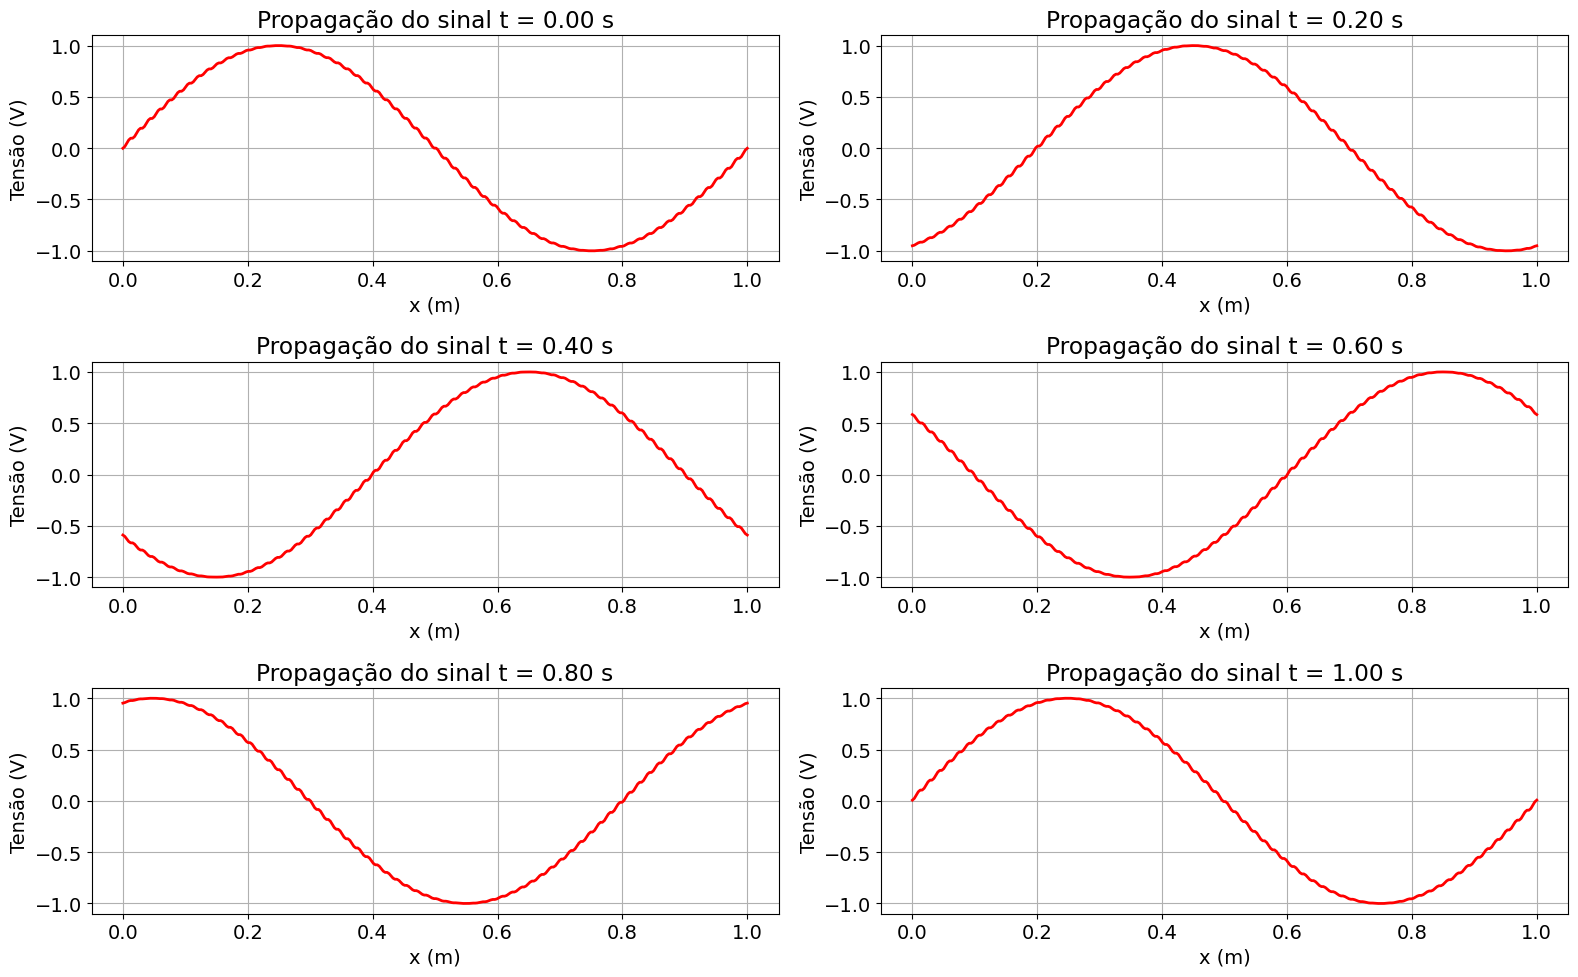

In [45]:
plt.rcParams.update({
    "font.size": 14
})

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    x_range = np.linspace(xl, xr, int(len(u_history[i].flatten())))
    ax.plot(x_range, u_history[i].flatten(), linewidth=2, color='red')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('Tensão (V)')
    ax.set_title(f'Propagação do sinal t = {dt * snapshots_list[i]:.2f} s')
    ax.grid()

plt.tight_layout()
plt.show()